In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from scipy.stats import ttest_1samp

In [36]:
df=pd.read_csv("bitcoin.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Month,Day,Year,Daily_Return,7-day MA,30-day MA,30-day Volatility
0,2015-01-01,320.434998,320.434998,314.002991,314.248993,8036550,1,1,2015,NaN,NaN,NaN,NaN
1,2015-01-02,314.079010,315.838989,313.565002,315.032013,7860650,1,2,2015,0.002492,NaN,NaN,NaN
2,2015-01-03,314.846008,315.149994,281.082001,281.082001,33054400,1,3,2015,-0.107767,NaN,NaN,NaN
3,2015-01-04,281.145996,287.230011,257.612000,264.195007,55629100,1,4,2015,-0.060079,NaN,NaN,NaN
4,2015-01-05,265.084015,278.341003,265.084015,274.473999,43962800,1,5,2015,0.038907,NaN,NaN,NaN


In [37]:
df.shape

(3560, 13)

In [38]:
df=df.dropna()

In [39]:
df.shape

(3530, 13)

In [40]:
df.tail()

,Date,Open,High,Low,Close,Volume,Month,Day,Year,Daily_Return,7-day MA,30-day MA,30-day Volatility
3555,2024-09-25,64302.589844,64804.503906,62945.375000,63143.144531,25078377700,9,25,2024,-0.018022,63421.699777,59364.688411,0.023105
3556,2024-09-26,63138.546875,65790.796875,62669.269531,65181.019531,36873129847,9,26,2024,0.032274,63741.780134,59553.917969,0.021436
3557,2024-09-27,65180.664062,66480.695312,64852.992188,65790.664062,32058813449,9,27,2024,0.009353,64112.878348,59779.352604,0.021355
3558,2024-09-28,65792.179688,66255.531250,65458.035156,65887.648438,15243637984,9,28,2024,0.001474,64468.993862,59996.001563,0.021355
3559,2024-09-29,65888.898438,66069.343750,65450.015625,65635.304688,14788214575,9,29,2024,-0.003830,64752.792969,60213.195833,0.021346


In [41]:
X=df.drop(['Close','Date'],axis=1)
y=df['Close']

In [42]:
# splitting X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [43]:
# import the regressor
from sklearn.ensemble import RandomForestRegressor
  
 # create regressor object
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
  
# fit the regressor with x and y data
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)

In [26]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('r2_score:',r2_score(y_test,y_pred))

Mean Absolute Error: 172.40483090548665
Mean Squared Error: 140582.07973355666
Root Mean Squared Error: 374.942768610833
r2_score: 0.9996673365045837


In [45]:
# Metrics calculation
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, y_pred)))

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print('Mean Absolute Percentage Error (MAPE):', mape)

# R-squared score
print('R-squared (R²):', r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 172.40483090548665
Mean Squared Error (MSE): 140582.07973355666
Root Mean Squared Error (RMSE): 374.942768610833
Mean Absolute Percentage Error (MAPE): 1.0446096940616003
R-squared (R²): 0.9996673365045837


In [11]:
import scipy.stats as stats

# Hypothesis Test
# Null Hypothesis (H0): The mean difference between predicted and actual values is 0 (no difference).
# Alternative Hypothesis (H1): The mean difference between predicted and actual values is not 0 (significant difference).

# Calculate the difference between predicted and actual values
difference = y_test - y_pred.flatten()

# Perform a paired t-test
t_stat, p_value = stats.ttest_1samp(difference, 0)

# Display the t-statistic and p-value
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Step 7: Conclusion of Hypothesis Test
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between predicted and actual values.")
else:
    print("Fail to reject the null hypothesis: No significant difference between predicted and actual values.")

T-statistic: -0.9295688233216983
P-value: 0.35284871211326696
Fail to reject the null hypothesis: No significant difference between predicted and actual values.


In [12]:
import pickle
pickle.dump(model, open('pickle.pkl','wb'))
model = pickle.load(open('pickle.pkl','rb'))

## LSTM

In [29]:

df.head(2)

,Date,Open,High,Low,Close,Volume,Month,Day,Year,Daily_Return,7-day MA,30-day MA,30-day Volatility
30,2015-01-31,226.440994,233.503998,216.309006,217.464005,23348200,1,31,2015,-0.039576,243.140429,246.600333,0.074958
31,2015-02-01,216.867004,231.574005,212.014999,226.972000,29128500,2,1,2015,0.043722,239.319571,243.664999,0.075558


In [30]:
df.dropna(inplace=True)

features = ["Open",	"High",	"Low",	"Close",	"Volume",	"Month",	"Day",	"Year",	"Daily_Return",	"7-day MA",	"30-day MA",	"30-day Volatility"]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features + ['Close']])

In [31]:

# Create sequences
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

lookback = 10
X, y = create_sequences(scaled_data, lookback)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build the LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(50, return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/home/asif/Projects/Bitcoin/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        12,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,851 (128.32 KB)

 Trainable params: 32,851 (128.32 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:

# Train the Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

# Evaluate the Model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R^2 Score:", r2)
print("Mean Squared Error:", mse)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0123 - val_loss: 0.0026
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.3090e-04 - val_loss: 0.0011
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2596e-04 - val_loss: 0.0015
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8323e-04 - val_loss: 0.0030
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9779e-04 - val_loss: 7.9163e-04
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9118e-04 - val_loss: 9.9297e-04
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.9719e-04 - val_loss: 0.0011
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0533e-04 - val_loss: 0.0012
Epoch 9/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2717e-04 - val_loss: 0.0017
Epoch 10/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4942e-04 - val_loss: 7.6012e-04
Epoch 11/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5047e-04 - val_loss: 8.3560e-04
Epoch 12/20
88/88 

In [33]:
import scipy.stats as stats

# Step 6: Hypothesis Test
# Null Hypothesis (H0): The mean difference between predicted and actual values is 0 (no difference).
# Alternative Hypothesis (H1): The mean difference between predicted and actual values is not 0 (significant difference).

# Calculate the difference between predicted and actual values
difference = y_test - y_pred.flatten()

# Perform a paired t-test
t_stat, p_value = stats.ttest_1samp(difference, 0)

# Display the t-statistic and p-value
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Step 7: Conclusion of Hypothesis Test
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between predicted and actual values.")
else:
    print("Fail to reject the null hypothesis: No significant difference between predicted and actual values.")

T-statistic: 19.225798233535205
P-value: 1.6215878480730992e-66
Reject the null hypothesis: There is a significant difference between predicted and actual values.


# Sarima

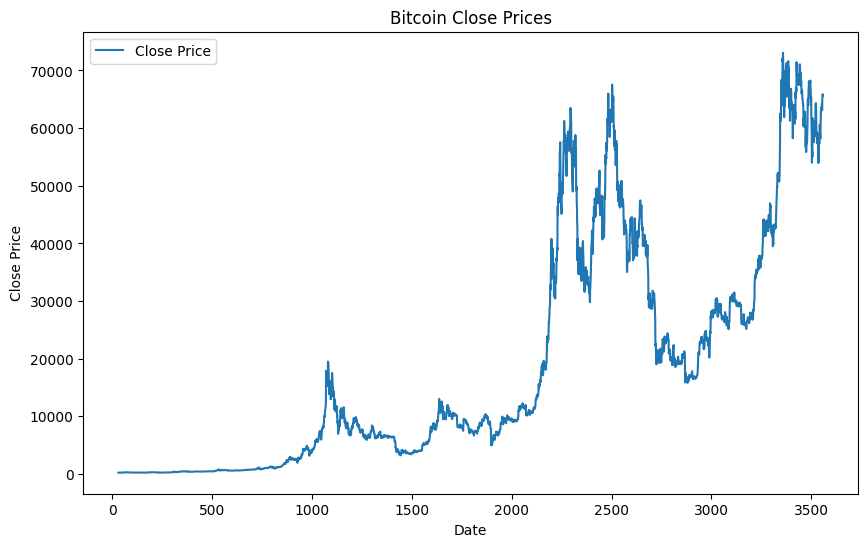

/home/asif/Projects/Bitcoin/myenv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/asif/Projects/Bitcoin/myenv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/asif/Projects/Bitcoin/myenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 2824
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -22758.705
Date:                            Sat, 25 Jan 2025   AIC                          45527.409
Time:                                    00:17:00   BIC                          45557.091
Sample:                                         0   HQIC                         45538.124
                                           - 2824                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9593      0.022     43.336      0.000       0.916       1.003
ma.L1         -0.9482      0.025   

/home/asif/Projects/Bitcoin/myenv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/asif/Projects/Bitcoin/myenv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


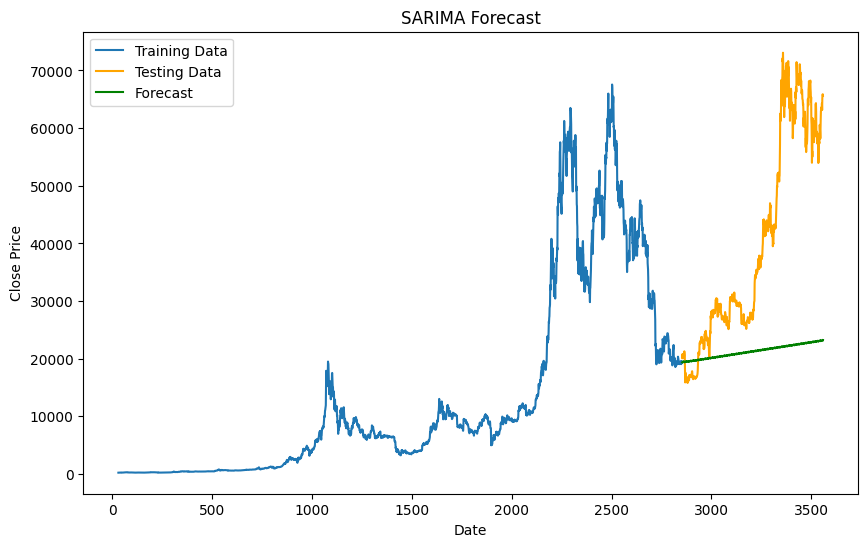

Mean Squared Error: 626001752.4010067


In [18]:

from statsmodels.tsa.statespace.sarimax import SARIMAX




# Use the 'Close' column as the target variable
time_series = df['Close']

# Plot the data to visualize the trend and seasonality
plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Close Price')
plt.title('Bitcoin Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Split data into training and testing sets
train_size = int(len(time_series) * 0.8)
train, test = time_series[:train_size], time_series[train_size:]

# Fit a SARIMA model (Adjust parameters (p, d, q)(P, D, Q, s) as needed)
model = SARIMAX(train, 
                order=(1, 1, 1),  # p, d, q
                seasonal_order=(1, 1, 1, 12),  # P, D, Q, s
                enforce_stationarity=False,
                enforce_invertibility=False)
sarima_model = model.fit(disp=False)

# Print the model summary
print(sarima_model.summary())

# Forecast future values
forecast_steps = len(test)
forecast = sarima_model.forecast(steps=forecast_steps)

# Plot the training, testing, and forecasted data
plt.figure(figsize=(10, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Testing Data', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluate the model performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test, forecast)
print(f'Mean Squared Error: {mse}')


In [ ]:

# Compute R-squared
r2 = r2_score(test, forecast)
print(f'R-squared: {r2}')


R-squared: -0.9848446729596263


In [ ]:
mape = mean_absolute_percentage_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'MAPE: {mape}, RMSE: {rmse}')


MAPE: 0.3907380768748402, RMSE: 25020.027026384418
